# DBSCAN LOOP para experimentación


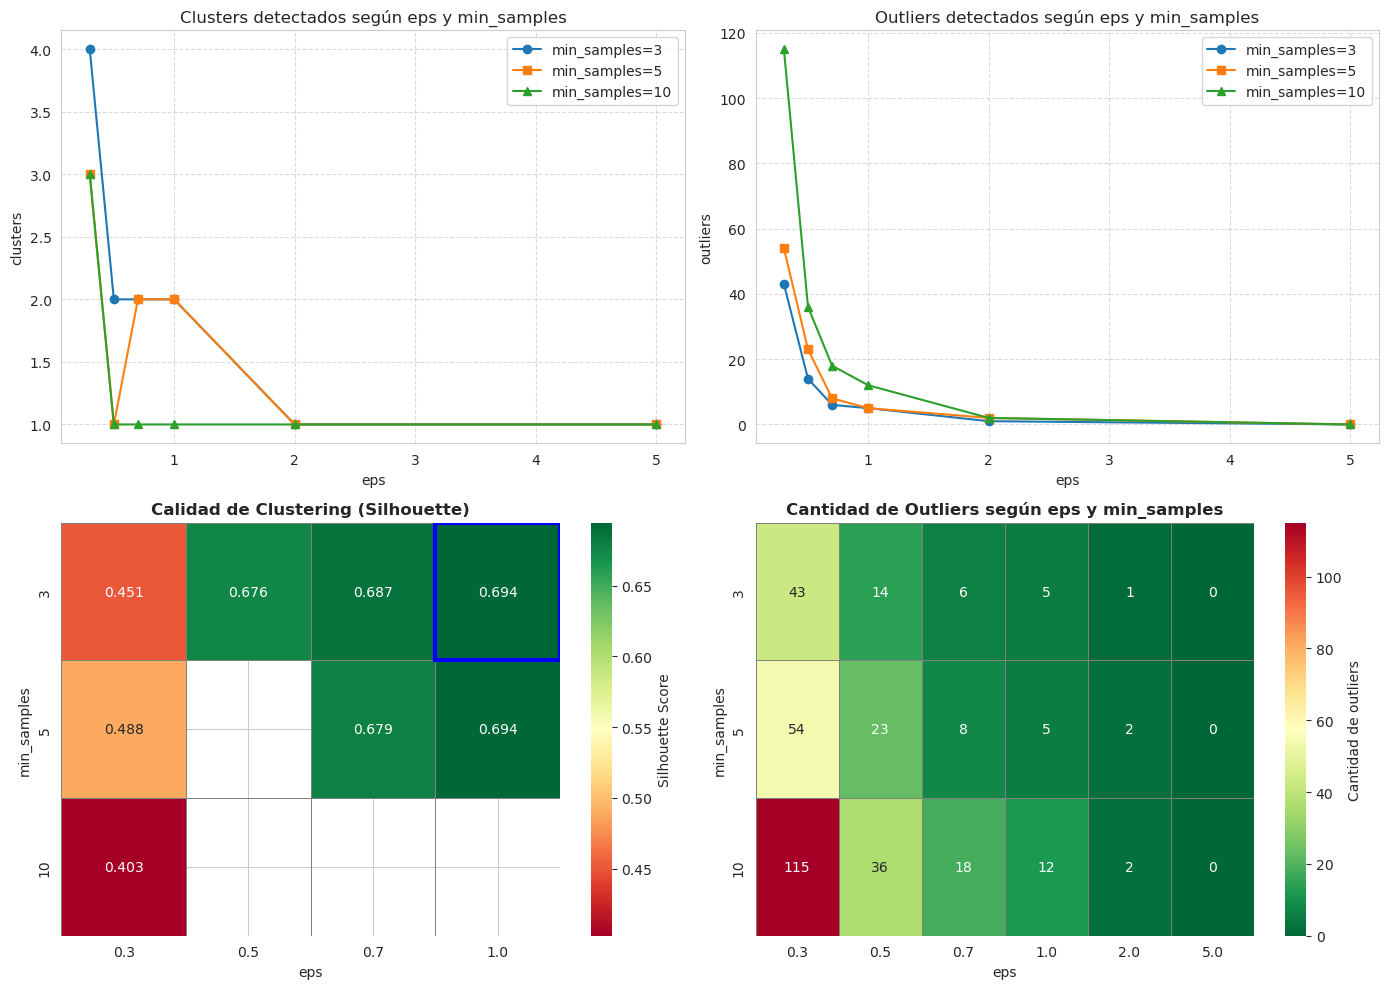


## Conclusión de Experimentos DBSCAN con PCA

Tras probar distintas combinaciones de parámetros:
- Mejor configuración encontrada: eps=1.0, min_samples=3.0
- Clusters detectados: 2.0
- Outliers detectados: 5.0
- Silhouette Score: 0.694

Esto sugiere que esta combinación ofrece la separación más clara entre clusters y ruido.  
El uso de PCA mejora la calidad del clustering al reducir ruido y redundancia en las variables originales.


In [15]:
# =========================
# LIBRERÍAS
# =========================
import os
from dotenv import load_dotenv
from pyspark.sql import SparkSession
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import Markdown
import pandas as pd

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# CONEXIÓN A MONGO
# =========================
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

spark = (
    SparkSession.builder
    .appName("AutoTec_Batch_Processing")
    .config("spark.mongodb.read.connection.uri", MONGO_URI)
    .config("spark.mongodb.write.connection.uri", MONGO_URI)
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1")
    .getOrCreate()
)

df = (
    spark.read.format("mongodb")
    .option("database", "proyecto_bigdata")
    .option("collection", "Contenedor_Autos_Limpio")
    .load()
)

# =========================
# PREPARAR DATOS PARA DBSCAN
# =========================
pdf = df.toPandas()
X = pdf[["precio", "kilometraje", "year"]].dropna().values

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================
# EXPERIMENTOS DBSCAN
# =========================
eps_values = [0.3, 0.5, 0.7, 1.0, 2.0, 5.0]
min_samples_values = [3, 5, 10]

resultados = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X_pca)
        labels = dbscan.labels_

        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        outliers = list(labels).count(-1)

        silhouette = None
        if clusters > 1:
            silhouette = silhouette_score(X_pca, labels)

        resultados.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": clusters,
            "outliers": outliers,
            "silhouette": silhouette
        })

df_results = pd.DataFrame(resultados)

# =========================
# GRÁFICOS
# =========================
sns.set_style("whitegrid")
palette = sns.color_palette("tab10", len(min_samples_values))
markers = ["o", "s", "^"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Clusters
ax1 = axes[0,0]
for i, min_samples in enumerate(min_samples_values):
    subset = df_results[df_results["min_samples"] == min_samples]
    ax1.plot(subset["eps"], subset["clusters"], 
             marker=markers[i % len(markers)], color=palette[i], 
             label=f"min_samples={min_samples}")
ax1.set_title("Clusters detectados según eps y min_samples")
ax1.set_xlabel("eps")
ax1.set_ylabel("clusters")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.7)

# Outliers
ax2 = axes[0,1]
for i, min_samples in enumerate(min_samples_values):
    subset = df_results[df_results["min_samples"] == min_samples]
    ax2.plot(subset["eps"], subset["outliers"], 
             marker=markers[i % len(markers)], color=palette[i], 
             label=f"min_samples={min_samples}")
ax2.set_title("Outliers detectados según eps y min_samples")
ax2.set_xlabel("eps")
ax2.set_ylabel("outliers")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.7)

# Heatmap Silhouette
df_heatmap = df_results.dropna(subset=["silhouette"])
pivot = df_heatmap.pivot(index="min_samples", columns="eps", values="silhouette")

ax3 = axes[1,0]
sns.heatmap(
    pivot, annot=True, fmt=".3f", cmap="RdYlGn", 
    cbar_kws={'label': 'Silhouette Score'}, 
    linewidths=0.5, linecolor="gray", ax=ax3
)
ax3.set_title("Calidad de Clustering (Silhouette)", fontsize=12, fontweight="bold")
ax3.set_xlabel("eps")
ax3.set_ylabel("min_samples")

if not df_heatmap.empty:
    best = df_heatmap.sort_values("silhouette", ascending=False).iloc[0]
    best_x = list(pivot.columns).index(best["eps"])
    best_y = list(pivot.index).index(best["min_samples"])
    ax3.add_patch(patches.Rectangle((best_x, best_y), 1, 1, fill=False, edgecolor='blue', lw=3))

# Heatmap Outliers
pivot_outliers = df_results.pivot(index="min_samples", columns="eps", values="outliers")

ax4 = axes[1,1]
sns.heatmap(
    pivot_outliers, annot=True, fmt="d", cmap="RdYlGn_r", 
    cbar_kws={'label': 'Cantidad de outliers'}, 
    linewidths=0.5, linecolor="gray", ax=ax4
)
ax4.set_title("Cantidad de Outliers según eps y min_samples", fontsize=12, fontweight="bold")
ax4.set_xlabel("eps")
ax4.set_ylabel("min_samples")

fig.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
plt.show()

# =========================
# CONCLUSIÓN AUTOMÁTICA
# =========================
if df_results.dropna(subset=["silhouette"]).shape[0] > 0:
    best_config = df_results.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).iloc[0]

    conclusion = f"""
## Conclusión de Experimentos DBSCAN con PCA

Tras probar distintas combinaciones de parámetros:
- Mejor configuración encontrada: eps={best_config['eps']}, min_samples={best_config['min_samples']}
- Clusters detectados: {best_config['clusters']}
- Outliers detectados: {best_config['outliers']}
- Silhouette Score: {best_config['silhouette']:.3f}

Esto sugiere que esta combinación ofrece la separación más clara entre clusters y ruido.  
El uso de PCA mejora la calidad del clustering al reducir ruido y redundancia en las variables originales.
"""
else:
    conclusion = """
## Conclusión de Experimentos DBSCAN con PCA

Ninguna configuración probada logró formar más de un cluster válido.  
Esto indica que DBSCAN no fue factible con los parámetros actuales.  
Se recomienda ajustar `eps` y `min_samples` o considerar otro algoritmo de clustering.
"""

display(Markdown(conclusion))

